<a href="https://colab.research.google.com/github/Mmbsaksd/transformers/blob/main/Transformers_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Context in Attention (x vs. y vectors)**

Context in Attention: x vs. y Vectors

The Problem: 'x' Vectors (No Context)
Basic word inputs (x) are like rigid dictionary definitions. The computer's version of the word "bank" is always exactly the same, no matter what sentence it is in. It doesn't know about its neighboring words.

The Solution: 'y' Vectors (Context-Aware)
After going through the "attention" mechanism, we get 'y' vectors. A 'y' vector is a smart mixture of the original word AND the words surrounding it.

Why 'y' is Better (The "Bank" Example):

  - In the sentence "I sat by the river bank", the 'y' version of "bank" will mix with the word "river".
  - In the sentence "I put money in my bank account", the 'y' version will mix with "money" and "account".

Conclusion:
Because 'y' mixes with the whole sentence, its final form changes depending on the context. This helps the AI understand multiple meanings of the same word, just like humans do!

In [1]:
import numpy as np

np.random.seed(42)

sentence = ["Bank", "of", "the", "river"]
seq_len = len(sentence)
d_model = 8

print(f"sentence: {sentence}")
print(f"seq_len = {seq_len}, d_model = {d_model}")

sentence: ['Bank', 'of', 'the', 'river']
seq_len = 4, d_model = 8


In [2]:
def build_embeddings(vocab_words, d_model, seed=0):
    rng = np.random.default_rng(seed)
    vocab = sorted(set(vocab_words))
    table = {w: rng.normal(size=d_model) for w in vocab}
    return table

vocab_words = ["bank", "of", "the", "river", "account", "money", "has", "today"]
embedding_table = build_embeddings(vocab_words, d_model, seed=0)

X = np.stack([embedding_table[w.lower()] for w in sentence])
print("X shape (seq_len, d_model):", X.shape)

for w, vec in zip(sentence, X):
    print(f"  x_{w:<6} shape={vec.shape}  dims={np.round(vec, 2)}")

X shape (seq_len, d_model): (4, 8)
  x_Bank   shape=(8,)  dims=[-0.7  -1.27 -0.62  0.04 -2.33 -0.22 -1.25 -0.73]
  x_of     shape=(8,)  dims=[-0.16  0.54  0.21  0.36 -0.65 -0.13  0.78  1.49]
  x_the    shape=(8,)  dims=[ 1.8   1.32  0.36 -1.21 -0.    0.66 -1.29  0.4 ]
  x_river  shape=(8,)  dims=[-1.26  1.51  1.35  0.78  0.26 -0.31  1.46  1.96]


**Q, K, V Projections (Attention Mechanism)**

Q, K, V Projections in Attention

The Goal:
Give each word vector three specific roles to figure out how words relate to each other.

The Roles:

  - Query (Q): What is this word looking for in the sentence?
  - Key (K): What information does this word have that others might want?
  - Value (V): The actual meaning of the word that will be used.

How it Works (The Projection):

  - Take the input word vector (x_i).
  - Multiply it by 3 different learned weight matrices (W_q, W_k, W_v).
  - Note: "Learned" just means the AI figures out the best numbers for these matrices during training.

The Matrix Shortcut:
Instead of doing this one word at a time, we stack all words into one big matrix X. Then, we can find all Qs, Ks, and Vs for the whole sentence at once using simple matrix multiplicatio

In [3]:
X

array([[-0.70373524, -1.26542147, -0.62327446,  0.04132598, -2.32503077,
        -0.21879166, -1.24591095, -0.73226735],
       [-0.15922501,  0.54084558,  0.21465912,  0.35537271, -0.65382861,
        -0.12961363,  0.78397547,  1.49343115],
       [ 1.80163487,  1.31510376,  0.35738041, -1.20831863, -0.00445413,
         0.65647494, -1.28836146,  0.39512206],
       [-1.25906553,  1.51392377,  1.34587542,  0.7813114 ,  0.26445563,
        -0.31392281,  1.45802068,  1.96025832]])

In [4]:
d_k = d_model

rng = np.random.default_rng(1)
W_q = rng.normal(scale=0.5, size=(d_model, d_k))
W_k = rng.normal(scale=0.5, size=(d_model, d_k))
W_v = rng.normal(scale=0.5, size=(d_model, d_k))

Q = X @ W_q
K = X @ W_k
V = X @ W_v

print("X:", X.shape, " W_q:", W_q.shape, " -> Q:", Q.shape)
print("K:", K.shape, "  V:", V.shape)

X: (4, 8)  W_q: (8, 8)  -> Q: (4, 8)
K: (4, 8)   V: (4, 8)


### **Attention Weights ($w_{ij}$) Explained Simply**

* **Raw Scores (`scores[i, j]`):** Every word looks at every other word in the sentence and asks, *"How relevant are you to my meaning?"* It assigns a raw number (score) to represent that connection.
* **Scaling (`/ sqrt(d_k)`):** We divide the raw scores by a specific number to shrink them down. If the raw numbers get too large, the AI's mathematical engine gets stuck. Scaling keeps the math stable (or "well-behaved").
* **Softmax:** A mathematical trick that converts the clunky raw scores into clean percentages (ranging from 0.0 to 1.0).
* **Summing to 1:** Just like a pie chart, a single word only has 100% of its attention to give. If a sentence has 4 words, the attention percentages it hands out to those 4 words must perfectly add up to 1.0 (100%).

In [5]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

scores = Q @ K.T / np.sqrt(d_k)
attn_weights = softmax(scores, axis=-1)

print("scores shape:", scores.shape, " (seq_len, seq_len)")
print("attention weights (rows = query word, cols = key word):\n")
header = "        " + "".join(f"{w:>8}" for w in sentence)
print(header)

for w, row in zip(sentence, attn_weights):
    print(f"{w:>8}" + "".join(f"{v:8.3f}" for v in row))
print("\nrow sums (should all be 1.0):", np.round(attn_weights.sum(axis=1), 6))

scores shape: (4, 4)  (seq_len, seq_len)
attention weights (rows = query word, cols = key word):

            Bank      of     the   river
    Bank   0.215   0.251   0.388   0.145
      of   0.074   0.255   0.161   0.509
     the   0.004   0.129   0.029   0.838
   river   0.071   0.223   0.450   0.256

row sums (should all be 1.0): [1. 1. 1. 1.]


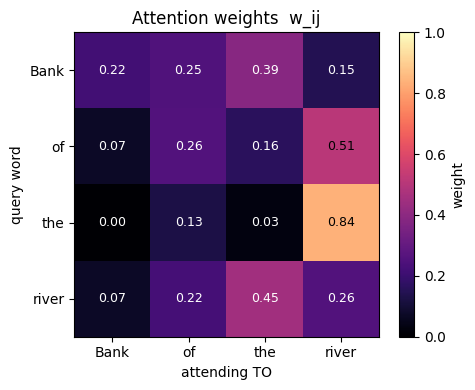

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(sentence)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO"); ax.set_ylabel("query word")
ax.set_title("Attention weights  w_ij")
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center",
                 color="white" if attn_weights[i,j] < 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()

### **Computing the Final Output ($Y$)**

* **The Final Mixture:** This step creates the final, context-aware versions of our words ($y_1, y_2, y_3, y_4$).
* **The Math (`Y = attn_weights @ V`):** To build the final meaning for the first word ($y_1$), the AI takes a percentage of Word 1, Word 2, Word 3, and Word 4, and adds them all together. The percentages used are exactly the **attention weights** we calculated in the previous step.
* **The Crucial Detail (Mixing $V$, not $X$):** The AI doesn't mix the raw, original word vectors ($X$) together. It mixes their **Values** ($V$). This is why we created the Value projections in the very first step—to isolate the actual underlying meaning that is worth passing along to the final output.

In [7]:
Y = attn_weights @ V   # (seq_len, d_k)  <-- this is y1, y2, y3, y4 stacked

print("Y shape (seq_len, d_k):", Y.shape)
for w, y_i, weights in zip(sentence, Y, attn_weights):
    contributors = ", ".join(f"w({w}->{sw})={wt:.2f}" for sw, wt in zip(sentence, weights))
    print(f"y_{w:<6} shape={y_i.shape}   {contributors}")

Y shape (seq_len, d_k): (4, 8)
y_Bank   shape=(8,)   w(Bank->Bank)=0.22, w(Bank->of)=0.25, w(Bank->the)=0.39, w(Bank->river)=0.15
y_of     shape=(8,)   w(of->Bank)=0.07, w(of->of)=0.26, w(of->the)=0.16, w(of->river)=0.51
y_the    shape=(8,)   w(the->Bank)=0.00, w(the->of)=0.13, w(the->the)=0.03, w(the->river)=0.84
y_river  shape=(8,)   w(river->Bank)=0.07, w(river->of)=0.22, w(river->the)=0.45, w(river->river)=0.26


In [9]:
print(attn_weights)
print(V)


[[0.21510644 0.25138293 0.38809574 0.14541489]
 [0.07404832 0.25513456 0.16142026 0.50939686]
 [0.00432016 0.1286904  0.02937849 0.83761095]
 [0.07067898 0.22266517 0.45018764 0.25646821]]
[[-0.62826329  2.32879639  0.8092464  -0.70849144  0.17324997 -1.60770532
  -1.56954173 -2.05646998]
 [ 0.02401896 -1.64695626 -0.18618049  0.48710021 -1.63646611  0.23674732
  -1.53551014  1.90816958]
 [ 0.10949364 -0.12212432 -0.70143997 -1.96317852 -0.95923133  0.88960658
   1.20349633 -2.23659169]
 [ 0.87454388 -3.01926332 -0.4533333   0.7953159  -1.90843175  0.55354272
  -0.80996334  3.28575217]]


In [10]:
print(Y)
print(sentence)

[[ 0.04056019 -0.39951936 -0.21087576 -0.67620283 -1.02390044  0.13943234
  -0.37432852 -0.35289308]
 [ 0.42277062 -1.8054686  -0.33173092  0.16004814 -1.53167871  0.366928
  -0.72630773  1.64728249]
 [ 0.7361211  -2.73444253 -0.42078775  0.66811442 -1.83655311  0.5133103
  -0.84746336  2.92315315]
 [ 0.23452856 -1.03144676 -0.41630439 -0.62144067 -1.27342504  0.48154041
  -0.11876891  0.11533874]]
['Bank', 'of', 'the', 'river']
